# <u>Intro to statistics, __part 2__: distribution sampling and the Monte Carlo technique</u>

## Introduction

Here we will learn how to draw random samples from statistical distributions, and use the sampled data for specific purposes (such as estimating the mean of a function). This approach is typically referred to as a Monte Carlo simulation. It is also widely used as a method for estimating failure probabilities in structural reliability analysis problems, and sensitivity analysis for uncertainty quantification in complex models.

# 2.1. Random sampling and Monte Carlo
In Engineering, we may often encounter situations where the inputs to a function or a model are random variables, or where the model itself behaves in a stochastic way. For such probabilistic problems there is no one single outcome that is representative, and instead we seek to describe the results in terms of some representative statistical properties such as e.g. a histogram, or the most likely outcome, or a range of values (confidence interval) where it is most likely that the result will fall into. While for some simpler problems it is possible to determine the statistics of the output analytically, in many cases this is not feasible. Then, a possible way of determining the output statistics is to simulate many different realizations of the input variables, and evaluate the model/function for all these realizations. As a result we get a random sample of the function outputs. 
As we know, the statistical properties of a random sample converge to the true population distribution as the sample size tends to infinity, meaning that the estimates based on this simulation will be more and more accurate if we simulate more realizations. This approach of random simulation is called a Monte Carlo simulation.

## 2.1.1 Sampling from a single stochastic variable with a parametric distribution

A basic and generally applicable example of random sampling is to draw i.i.d. (independent and identically distributed) samples from a single random variable described by a parametric probability distribution. This can be done in two simple steps for *any form of distribution*:

1) Generate a sample of uniformly distributed values in the range of 0 to 1 (all programming languages have such random number generation). Note that the CDF (Cumulative Distribution Function) of a variable also is defined in the range of 0 to 1. 
2) Apply the inverse CDF function of the parametric distribution to each uniformly sampled value from point 1 above, transforming it from a uniform distribution to the desired CDF and PDF. 

Given that the 0-1 range is a universal property of the CDF of probability distributions, and that a uniform sampling means the 0-1 range is covered uniformly, we can expect that the outcome of this sampling technique will converge to the target probability distribution when the sample size tends to infinity. Further, the approach is applicable to any parametric probability distribution which has a defined inverse CDF function. 




In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

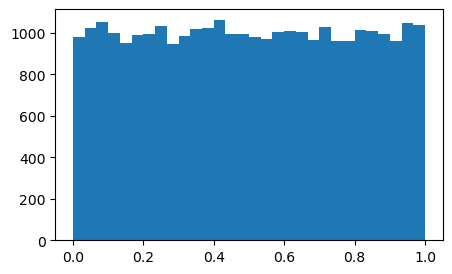

In [3]:
# STEP 1: Use np.random.rand to generate uniformly distributed data

Funit = np.random.rand(30000)
plt.figure(figsize=(5,3)); plt.hist(Funit,30);
plt.show();

### **Coding Task 2.1:**  sampling and bins...

Let us try the distribution sampling technique, using the inverse CDF to convert uniform data to a distribution of your choice (say Gaussian) in scipy.stats.
First generate a random sample following a normal distribution, with standard deviation 5 and mean 3.
Let's try it also using 'canned' scipy and numpy Gaussians...

In [ ]:
# Example with a Gaussian distribution:
X = stats.norm.ppf(Funit, loc = , scale = )  # Percent point function (inverse of CDF-percentiles)
X1 = stats.norm.rvs(loc = 3, scale = 5, size = )
X2 = np.random.randn(10000)*something + theMean
fig, ax = plt.subplots(1,3, figsize = (12,4))
plot1 = ax[0].hist(X, 20);  
plot2 = ax[1].hist(X1,30); 
plot3 = ax[2].hist(X2,30); 
plt.show()

### Now generate a random sample following a 2-parameter Weibull distribution with $A = 10.15$ and $k = 2$. Try different sample sizes, e.g., 100, 1000, 10000, and plot sample histograms. (Hint: use a function that provides the inverse Weibull distribution, e.g., ```stats.weibull_min.ppf``` in Python).

In [ ]:
# Code for generating a 2-parameter Weibull random sample
import numpy as np
import scipy.stats as stats

N1 = 100; N2 = 1000; N3 = 10000
Fw1 = np.random.rand(N1); Fw2 = np.random.rand(N2); Fw3 = np.random.rand(N3)

A = 
k = 

x1 = stats.weibull_min.ppf(   , c= , scale= , loc = 0)

import matplotlib.pyplot as plt
fig1, axs1 = plt.subplots(1,3,figsize = (16,4))
axs1[0].hist(x1,30)
axs1[1].hist(x2,30)
axs1[2].hist(x3,30)
plt.show();

#### * Does the number of bins needed, per number of realizations (total samples), differ for a Weibull, compared to the Gaussian?
#####  * How can we deal with this?  [Hint: it depends...]
If we repeat the sample generation for $n$ number of times, what will the distribution of the sample means $(\bar{X}_1, \bar{X}_2, \ldots, \bar{X}_n)$ be?


## 2.1.2 Monte Carlo simulation and integration

With the Monte Carlo approach, we randomly choose points within the domain of interest, and evaluate the function at each point. Since the points are drawn fully randomly from their underlying distributions without a preference of one point over another, we can treat all drawn samples as equally likely, and apply equal weight to each of them. Then, according to the law of large numbers, the mean of the outcomes, represented by the simple summation below, will gradually converge to the true mean of the function:

$Q_N = \frac{1}{N} \sum_{i=1}^Nf(x_i),  =>   \lim_{n\to \infty} Q_N = \langle f(x) \rangle$

As you have seen in one of the videos in the course introduction, the Monte Carlo approach can also be used for numerical integration. This is done by simply adding the volume of the integration domain of the definite integral we want to compute:

$I \approx V \frac{1}{N}\sum_{i=1}^N f(x_i)$



## Running a Monte Carlo simulation

A typical Monte Carlo simulation has the same two steps discussed earlier in relation to drawing random samples of a probability distribution:

### 1) Drawing random samples of the input variables

The first step in a Monte Carlo simulation is to draw samples of the input random variables. This may not be as straightforward as it sounds, because the random variables may have very different distributions, and may be correlated. Therefore, the generation of the random samples is normally done in two steps: 

#### 1.1) Random i.i.d. samples

For a Monte Carlo simulation with $m$ input variables (or dimensions as we often call them), we first generate a set of i.i.d. (independent and identically distributed) random samples. A widely used choice of i.i.d. variables is uniformly distributed variables in the range $(0,1]$ or variables following the standard Normal distribution. 

#### 1.2) Isoprobabilistic transformation

Having generated the random i.i.d. samples, we need to transform them into samples of the random variables required in the specific problem, taking into account distribution parameters and correlations. This is done using a so-called isoprobabilistic transformation. The "isoprobabilistic" transformation name is due to the requirement that the transformation should retain the cumulative probability of each sample point (e.g. each point has the same cdf after the transformation). If the variables are correlated, there are normally two types of transformations applied - a Nataf transformation which uses the Pearson's correlation coefficient (which defines linear correlation only!), or a Rosenblatt transformation, where the variable dependencies are represented in terms of a series of conditional distributions. In case there is no correlation involved, the transformation is quite straightforward - if the i.i.d. samples are uniformly distributed in the range $(0,1]$, then they are simply considered as representing the cdf values of the "physical-space" random variables. Then the actual "physical" values of the variables are computed by independently taking the inverse-cdf of the respective probability distribution of each variable.

### 2) Evaluating the function

Having the input variables ready, the function or model under consideration is simply evaluated for each random realization of the inputs and thus a random sample of the model outcome is created.


## Convergence and statistics of outputs

Monte Carlo is a stochastic method, meaning that independent runs will yield different results, and the end result convergence and uncertainty will depend on the number of samples. The uncertainty in the Monte Carlo estimate (for example for the mean $Q_N$ of a function $f(x)$) will be related to the variance of the function being simulated. The variance of $f(x)$ can be computed from the Monte Carlo sample variance:

$Var(f(x)) \approx \frac{1}{N-1} \sum_{i=1}^N E[(f(x_i) - \langle f(x)\rangle)^2]$

Then, the variance of the estimate (e.g., the numerical integral) can be estimated as:

$Var(Q_N) = \frac{V^2}{N^2}\sum_{i=1}^N Var(f) = V^2 \frac{Var\{f\}}{N} = V^2 \frac{E(\sigma_N^2)}{N}$


### **Coding Task 2.2:**

Let us now try to run a Monte Carlo simulation with multiple variables that serve as function inputs. We want to determine the mean value of the function $y=x_1^2+3x_2$, where $x_1$ and $x_2$ are Normally distributed, uncorrelated random variables, and $x_1$ has mean of 0 and standard deviation of 2, and $x_2$ has mean of 4 and standard deviation of 1. 

Let us try the following:

- Implement a Crude Monte Carlo as described above, to compute the mean of the function $y = f(x_1,x_2)$
- Estimate the variance of the estimate using the formulas above. Illustrate the MC convergence process by plotting the evolution of this variance along with the evolution of the mean prediction, as function of the number of samples
- Try different sampling strategies (e.g. regular grid, crude Monte Carlo, quasi-random sequences). Are there any differences in the convergence speed and accuracy?


Doing the exercise tasks requires definitions of some statistical distributions and random sampling methods, and a suitable library containing such functions is OpenTURNS. Run the cell below to install OpenTURNS in case they are not installed on your system.

In [ ]:
pip install openturns

In [6]:
### Let us import the libraries we need:
import openturns as ot

## Drawing random i.i.d samples
Now let us generate the random samples to fill in a 2-D space with 2 independent and identically distributed (i.i.d) variables in the interval [0,1].  We will first need to define the marginal distributions (in this case we pick Gaussians: the first with 0 mean and standard deviation 2, the second with mean 4 and std.dev.=1), then decide on a sampling strategy. We will try four sampling strategies:
 - Regular grid
 - A Crude Monte Carlo, where pseudorandom numbers are drawn in the interval (0,1) as in np.rand.rand()
 - Latin Hypercube Sampling (LHS) 
 - The quasi-random _Halton_ sequence
 
In the cell below, we first use a uniform marginal distribution on the interval (0,1), then define 2 independent variables $\{F_1,F_2\}$ with this specified marginal distribution. We then make a "joint" distribution based on Gaussian $\{X_1,X_2\}$ calculated from $\{F_1,F_2\}$; this is done using several different sampling strategies. For comparison purposes, we also manually generate a regularly spaced grid with the same bounds. 

#### After this we will look at how these sampling strategies affect the calculated statistics of a nonlinear function of these two variables.
The nonlinear function we'll try here is $g\equiv X_1^2+3X_2$.

In [121]:
N = int(1e6)
F1 = np.random.rand(N);  F2 = np.random.rand(N)
X1 = stats.norm.ppf(  );  
X2=stats.norm.ppf(  )
## advanced example: X1=Gaussian {mean=1, stdev=5};  X2=Weibull {A=10, k=1.5}
#X1 = stats.norm.ppf(F1, loc=1, scale=5);  X2 = stats.weibull_min.ppf(F2, scale=10, c=1.5)
g = 

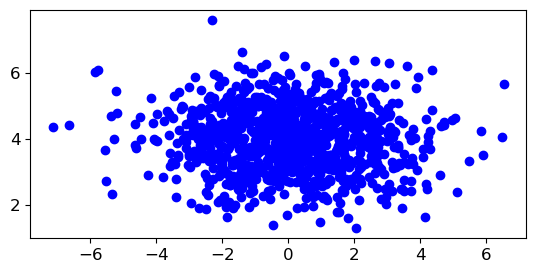

In [122]:
plt.plot(X1[:1000],X2[:1000],'ob')
current_axis = plt.gca();  current_axis.set_aspect('equal','box')

#### Now find the mean and variance of the nonlinear function $g$:

In [ ]:
gMean=
gVar=
print('Mean of g='+ str(round(gMean,2)), '; Variance of g=' + str(round(gVar,2)))

### But, can't we just find these via "pencil and paper", given the functional description?
##### What are the 'perfect' (theoretical) mean and variance here? 
To start:  $g\equiv X_1^2+3X_2$, and we have $\mu_1=0$, $\sigma_1=2$ along with $\mu_2=4$ and $\sigma_2=1$. 

And a hint (from 46100 course): for uniform normalized Gaussians, the even $n^{th}$ moments are given by $E[x^n]=(n-1)E[x^{n-2}]$

### Estimate the sampling uncertainty of the Monte Carlo 'simulation', as a function of sample size.
##### Plot in log-log coordinates to show the behavior...

In [ ]:
SampleSizes = [1e2, 1e3, 1e4, 1e5, 1e6]
Uncertainty = [np.std(g)/np.sqrt(i) for i in SampleSizes]
plt.figure(figsize=(5,3)); plt.plot(SampleSizes,Uncertainty,'-or'); 
plt.xscale('log'); plt.yscale('log'); 

note: we could have calculated the uncertainty of means and standard deviations, by "brute force" through doing many _SETS_ of simulations

In [ ]:
fig,ax = plt.subplots(1,3,figsize = (15,5))
ax[0].plot(F1[:500],F2[:500],'ok',markersize = 3)
ax[0].set_aspect('equal','box')
ax[1].hist(X2,30)
ax[2].plot(X1[:1000],X2[:1000],'ok',markersize = 3)
plt.show()

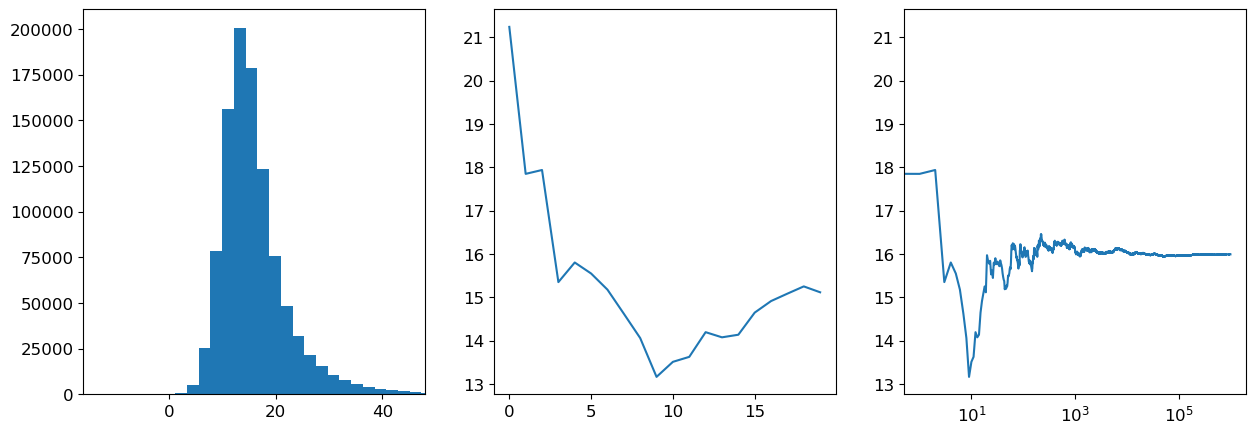

In [127]:
fig,ax = plt.subplots(1,3,figsize = (15,5))
ax[0].hist(g,50);  #  ax[0].set_yscale('log')
ax[0].set_xlim([gMean-5*np.sqrt(gVar),gMean+5*np.sqrt(gVar)]);  # try ± 5 stdevs for plotrange
ax[1].plot(np.cumsum(g[:20])/(np.arange(20)+1)); 
ax[2].plot(np.cumsum(g)/(np.arange(N)+1)); ax[2].set_xscale('log')
#p21 = ax[1].plot(np.arange(1,N_samples+1,1),np.cumsum(Yfunc(X1_MC,X2_MC))/np.arange(1,N_samples+1,1),'-b')
plt.show()

In [128]:
# GENERATE RANDOM VARIATES WITH OTHER SAMPLING TECHNIQUES

N_samples=200;  dim=20
ot.RandomGenerator.SetSeed(0)
uniform_distribution = ot.ComposedDistribution([ot.Uniform(0., 1.)] * dim)

# Crude Monte-Carlo
#SMC = np.random.rand(N_samples,dim)
SMC = uniform_distribution.getSample(N_samples)

# Latin hypercube (LHC)
LHSexperiment = ot.LHSExperiment(uniform_distribution, N_samples, False, True)
SLHC = LHSexperiment.generate();   

# Quasi- Monte Carlo (QMC)
QMCexperiment = ot.LowDiscrepancyExperiment(ot.SobolSequence(), uniform_distribution, N_samples, False)
SQMC = QMCexperiment.generate()

# Regular grid for comparison
STX,STY = np.meshgrid(np.linspace(0.001,0.999,30),np.linspace(0.001,0.999,30)) # regular grid for comparison

In [129]:
SLHC

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=200 dimension=20 description=[X0,X1,X2,...,X17,X18,X19] data=[[0.55699,0.405881,0.112792,...,0.51096,0.893972,0.0473188],[0.835743,0.704462,0.603535,...,0.971653,0.0877876,0.528578],[0.282607,0.686096,0.990672,...,0.695157,0.236768,0.780493],...,[0.389375,0.310678,0.327973,...,0.0486751,0.880546,0.624021],[0.588484,0.242798,0.499847,...,0.104564,0.735626,0.902543],[0.51161,0.673178,0.94881,...,0.325218,0.363214,0.759534]]

In [ ]:
# Plot and compare the output of the random number generators
fig, axs = plt.subplots(1,4,figsize = (16,4))
axs[0].plot(STX,STY,'ok');  #axs[0].axis([0, 1, 0, 1])
axs[0].set_xlabel("X"); axs[0].set_ylabel("Y"); axs[0].set_title("Regular grid")
axs[0].set_aspect('equal','box')
axs[1].plot(SMC[:,10],SMC[:,11],'ok');  #axs[1].axis([0,1,0,1])
axs[1].set_xlabel("X"); axs[1].set_ylabel("Y"); axs[1].set_title("Crude Monte Carlo")
axs[1].set_aspect('equal','box')
axs[2].plot(SLHC[:,10],SLHC[:,11],'ok');  #axs[2].axis([0,1,0,1])
axs[2].set_xlabel("X"); axs[2].set_ylabel("Y"); axs[2].set_title("Latin Hypercube")
axs[2].set_aspect('equal','box')
axs[3].plot(SQMC[:,16],SQMC[:,17],'ok');   #axs[3].axis([0,1,0,1])
axs[3].set_xlabel("X"); axs[3].set_ylabel("Y"); axs[3].set_title("Quasi Monte Carlo")
axs[3].set_aspect('equal','box')

fig.tight_layout();  plt.show();

## Convert the uniform samples to the actual distribution

Now let us convert our samples in "Physical" space. We want to generate a normal distribution with two variables $(X_1, X_2)$, where $X_1$ has mean 0 and standard deviation 2, and $X_2$ has mean 4 and standard deviation 1 (note that for simplicity we leave correlations out of the picture for now). For doing the transformation, we'll need to use the inverse cumulative normal distribution, which converts cumulative probability (cdf) values into "physical" space. Can you do this yourself using the scipy implementation?

In [131]:
X1_T = stats.norm.ppf(STX, loc = 0, scale = 2)
X2_T = stats.norm.ppf(STY, loc = 4, scale = 1)

X1_MC = stats.norm.ppf(SMC[:,0], loc = 0, scale = 2)
X2_MC = stats.norm.ppf(SMC[:,1], loc = 4, scale = 1)

X1_LHC = stats.norm.ppf(SLHC[:,0], loc = 0, scale = 2)
X2_LHC = stats.norm.ppf(SLHC[:,1], loc = 4, scale = 1)

X1_QMC = stats.norm.ppf(SQMC[:,0], loc = 0, scale = 2)
X2_QMC = stats.norm.ppf(SQMC[:,1], loc = 4, scale = 1)

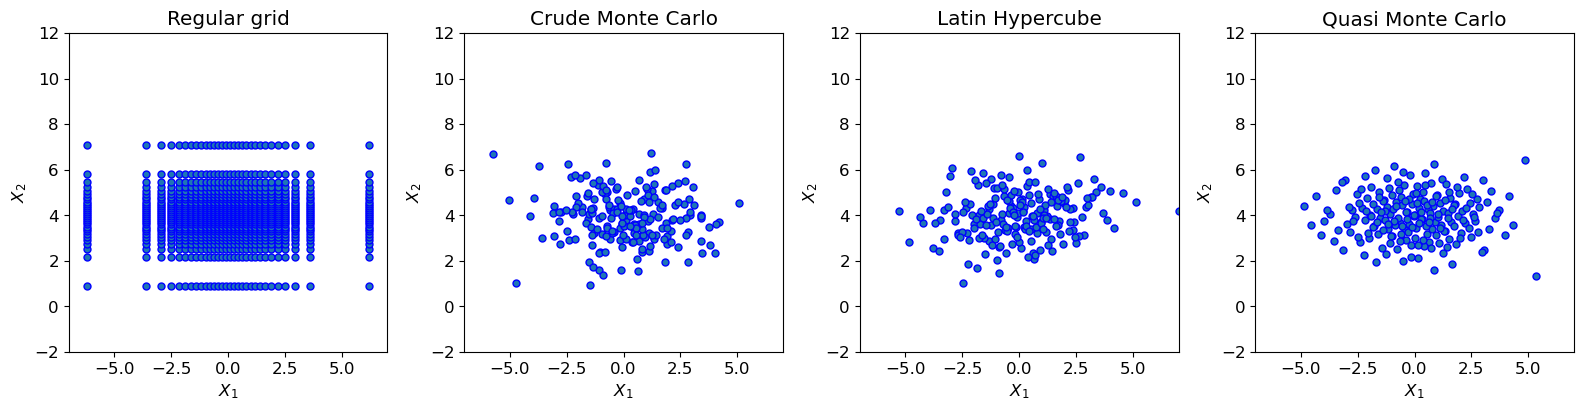

In [132]:
# Plot and compare the random variable outputs in physical space
plt.rc('font', size=12) 
fig1, axs1 = plt.subplots(1,4,figsize = (16,4))
plt.setp(axs1,xlabel = "$X_1$", ylabel = "$X_2$", aspect = 'equal', xlim = (-7,7),ylim = (-2,12))
plt.setp(axs1[0],title = "Regular grid")
plt.setp(axs1[1],title = "Crude Monte Carlo")
plt.setp(axs1[2],title = "Latin Hypercube")
plt.setp(axs1[3],title = "Quasi Monte Carlo")
p1 = axs1[0].plot(X1_T,X2_T,'ob')
p2 = axs1[1].plot(X1_MC,X2_MC,'ob')
p3 = axs1[2].plot(X1_LHC,X2_LHC,'ob')
p4 = axs1[3].plot(X1_QMC,X2_QMC,'ob')

plt.setp(p1,marker = 'o', markerfacecolor = 'C0',markersize = 5)
plt.setp(p2,marker = 'o', markerfacecolor = 'C0',markersize = 5)
plt.setp(p3,marker = 'o', markerfacecolor = 'C0',markersize = 5)
plt.setp(p4,marker = 'o', markerfacecolor = 'C0',markersize = 5)

fig1.tight_layout()
plt.show()

The "regular" grid is not so regular anymore!



## The "Monte Carlo" simulation

Now, let us define a simple function of $X_1$ and $X_2$:

In [133]:
def Yfunc(X1,X2): return X1**2 + 3*X2

Our task is to compute the mean of the function. A simple operation using np.mean():

In [ ]:
Mu_T = 
Mu_MC = 
Mu_LHC = 
Mu_QMC = 

print('Manual table: ' + str(round(Mu_T,1)))
print('Crude Monte Carlo: ' + str(round(Mu_MC,1)))
print('Latin Hypercube: ' + str(round(Mu_LHC,1)))
print('Halton sequence (quasi-MC): ' + str(round(Mu_QMC,1)))

The result from the tabular approach does not agree with the MC simulations! Why is this the case? Let us remind ourselves of the definition of the mean (expected) value of a random variable:

$E(X) = \int_{-\infty}^{\infty}X \cdot f(X)\mathrm{d}X$

where $f(X)$ is the probability density function of $X$. What is the difference between a manually-defined table and a Monte Carlo simulation, and how can this be taken into account when computing the expected value?

Let us plot the convergence of the three Monte Carlo simulations. As seen on the rightmost figure, the quasi-Monte Carlo approach leads to faster convergence of the expected value. This is because the quasi-random series have lower discrepancy than the "standard" pseudorandom numbers.

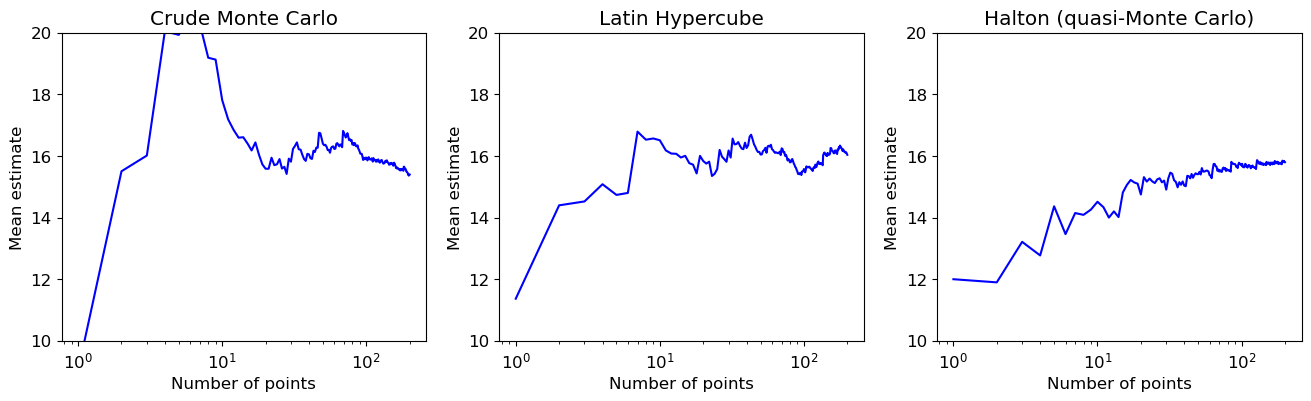

In [137]:
fig2, axs2 = plt.subplots(1,3,figsize = (16,4))
plt.setp(axs2,xlabel = "Number of points", ylabel = "Mean estimate", ylim = (10,20)); 
plt.setp(axs2[0],title = "Crude Monte Carlo"); axs2[0].set_xscale('log')
plt.setp(axs2[1],title = "Latin Hypercube"); axs2[1].set_xscale('log')
plt.setp(axs2[2],title = "Halton (quasi-Monte Carlo)"); axs2[2].set_xscale('log')
p21 = axs2[0].plot(np.arange(1,N_samples+1,1),np.cumsum(Yfunc(X1_MC,X2_MC))/np.arange(1,N_samples+1,1),'-b')
p22 = axs2[1].plot(np.arange(1,N_samples+1,1),np.cumsum(Yfunc(X1_LHC,X2_LHC))/np.arange(1,N_samples+1,1),'-b')
p23 = axs2[2].plot(np.arange(1,N_samples+1,1),np.cumsum(Yfunc(X1_QMC,X2_QMC))/np.arange(1,N_samples+1,1),'-b')
plt.show()


# 2.3 Bootstrap-resampling ("Bootstrapping")

Bootstraping is a technique where the distribution of a quantity of interest (e.g. of a random variable Y) is determined non-parametrically and purely empirically, by creating a number of realisations of an input sample $\mathbf{x_1, x_2, \ldots, x_l}$. The bootstrap samples are drawn from the original input sample the following way: 
1) First, all the data points from the input sample of size $N$ are given an integer index number $[1,N]$. 
2) Then a new bootstrap sample of size $N$ is created by drawing $N$ random integers from the interval $[1,N]$. The new sample is constructed from the datapoints from the original sample with indexes corresponding to the generated set of integers. Since the drawing procedure allows number repetitions, the resulting sample will in most cases differ from the original sample.

Although bootstrapping doesn't miraculously provide additional data, it generates variability by sampling subsets of the original data, thus leaving random points out of the sample. 

Bootstrapping can be used to better assess the distribution of the sample and the presence of outliers or high variance in general. For example, one can use bootstrapping to estimate the uncertainty in the sample statistics without making an assumption about the distribution of the sample. We will illustrate this in the following coding task.

*(However, note with real data, unlike the random synthesized data used here, when doing bootstrap-resampling we might need to consider whether each 'bootstrap' is long enough to contain representative information, i.e. longer than the integral time scale.  We will approach this later.)*


### **Coding Task 2.3:**

Let us demonstrate how a Bootstrap sample can be useful for interpreting resuls:

1) Draw a random Weibull sample of size 100 (A = 11.28 and k = 2) and compute its histogram using 30 bins
2) Apply bootstrapping to the sample and make a histogram using the same 30 bins
3) Plot the two histograms alongside each other


In [138]:
# GENERATE THE FIRST SAMPLE
N0 = 100
W = stats.weibull_min.ppf(np.random.rand(N0), loc = 0, scale = 11.28, c = 2)

Whist = np.histogram(W,bins = 30)
Wcounts = Whist[0];  Wbins = Whist[1]
Wbincenters = Wbins[:-1] + np.diff(Wbins)[0]/2

In [139]:
# BOOTSTRAP THE ORIGINAL SAMPLE "W"
Nbootstrap = 100000
BootstrapSize = len(W)
Bsample = np.random.choice(W, size = (BootstrapSize,Nbootstrap))
BootstrapMeans = np.sort(Bsample.mean(0))

In [140]:
# RESHAPE THE BOOTSTRAP SAMPLE, from 30xN TO A SINGLE COLUMN OF VALUES
Bsample_reshaped = Bsample.reshape(Nbootstrap*BootstrapSize)
Whist_bootstrap = np.histogram(Bsample_reshaped,bins = Wbins)
Wcounts_bootstrap = Whist_bootstrap[0]

In [ ]:
fig3,ax3 = plt.subplots(1,2,figsize = (10,4))
ax3[0].bar(Wbincenters,Wcounts)
ax3[1].bar(Wbincenters,Wcounts_bootstrap);

### What does the above figure tell us? We are not inventing new data, the histogram stays exactly the same! 
#### Any thoughts on how to improve this? 

One trick that could be done is to introduce a small random "noise" component to each sample point (see code below). Other possibilities are to compute the distribution moments (mean, standard deviation, skewness, etc.) from each of the bootstrap samples, and average those. 

In [142]:
Whist_N = np.histogram(W*(1 + np.random.randn(len(W))*0.1), bins = 30)
Wcounts_N = Whist_N[0]
Wbins_N = Whist_N[1]
Wbincenters_N = Wbins_N[:-1] + np.diff(Wbins_N)[0]/2

Whist_bootstrap_N = np.histogram(Bsample_reshaped*(1 + np.random.randn(len(Bsample_reshaped))*0.1), bins = 30)
Wcounts_bootstrap_N = Whist_bootstrap_N[0]
Wbins_bootstrap_N = Whist_bootstrap_N[1]
Wbincenters_bootstrap_N = Wbins_bootstrap_N[:-1] + np.diff(Wbins_bootstrap_N)[0]/2

In [ ]:
fig4,ax4 = plt.subplots(2,2,figsize = (10,10))
ax4[0,0].bar(Wbincenters,Wcounts)
ax4[0,1].bar(Wbincenters,Wcounts_bootstrap)
ax4[1,0].bar(Wbincenters_N,Wcounts_N)
ax4[1,1].bar(Wbincenters_bootstrap_N,Wcounts_bootstrap_N);

## Distribution of the sample mean using bootstrapping

We saw an example where bootstrapping doesn't work. Now, let us have an example where it is actually useful! Each of the *Nbootstrap* samples is a randomized sample with replacement from the original sample. If we compute the mean from each of these samples, we will get an estimate of how uncertain this mean is, and can draw a histogram / empirical probability distribution for the mean. 

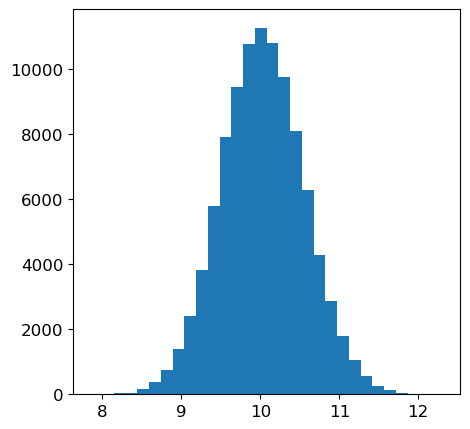

In [144]:
fig4,ax4 = plt.subplots(1,1,figsize = (5,5))
ax4.hist(BootstrapMeans, 30)
plt.show()

## Additional note: confidence intervals using bootstrapping

Confidence intervals can be obtained based on the variance of the bootstrap sample. If one wants to avoid the assumption of normality of the data (which is often taken when computing confidence intervals), the empirical cumulative distribution function (CDF) of the means from bootstrap samples can be used to compute a confidence interval without assumptions of distribution shape. This technique, along with other confidence interval computing techniques, will be discussed later in the course. 

## Additional exercise - generate correlated random variables

Let us try to generate a pair of correlated random variables. Normally this can be done in a two-step procedure: [1] generate a set of uncorrelated random variables; then [2] apply a transformation which modifies the variables to make them correlated. If the correlation is linear (i.e. can be described using Pearson's correlation coefficient), a suitable transformation is the Nataf transformation. With this method, a set of correlated random variables $Z$ is derived from a set of uncorrelated random variables $U$ by applying a linear transformation with the matrix $L$, and $Z = LU$. The *transformation matrix* $L$ is derived from the correlation between the random variables which are collected in a *correlation matrix* $R$. For example, for two random variables with correlation coefficient $\rho$, $R = [ [1, \rho],[\rho, 1]]$. $L$ is determined such that $LL^T = R$, meaning that $L$ can be obtained by carrying out an orthogonal decomposition of $R$. This is easily done using the Cholesky decomposition (*np.linalg.cholesky()*).
Let us try this below and generate a pair of standard normal random variables with correlation coefficient $\rho = 0.7$.

In [104]:
rho = 0.7

R = np.array([[1, rho], [rho, 1]])
L = np.linalg.cholesky(R)

N = 10000

U1 = np.random.randn(N)
U2 = np.random.randn(N)
U = np.array([U1,U2])
# Do we have correlation between U1 and U2?
print('Correlation coefficient of raw data: ' + str(np.corrcoef(U)[0,1]))

Z = np.dot(L,U)

# Did we get the right correlation between Z1 and Z2?
print('Correlation coefficient of transformed data: ' + str(np.corrcoef(Z)[0,1]))


Correlation coefficient of raw data: 0.0031220825027604387
Correlation coefficient of transformed data: 0.7031312400979565


In [105]:
U.shape

(2, 10000)

In [ ]:
fig3, axs3 = plt.subplots(figsize = (5,5))
axs3.plot(Z[0],Z[1],'o',markersize = 3)
axs3.set_xlim((-4,4)); axs3.set_ylim((-4,4));
axs3.set_aspect('equal')
axs3.set_xlabel('$Z_1$'); axs3.set_ylabel('$Z_2$');
plt.show();